# PowerLens — 01. Data Loading & Quality Check

> **KaynorData** · Descriptive Analytics · Energy Domain

---

## Objectif de ce notebook

1. Charger le dataset UCI Household Power Consumption
2. Inspecter la structure et les types de données
3. Identifier et traiter les valeurs manquantes
4. Parser les colonnes datetime
5. Sauvegarder un dataset propre pour les notebooks suivants


## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# Affichage élargi
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Imports OK')

Imports OK


## 1. Chargement des données

Le dataset utilise `;` comme séparateur et `?` pour les valeurs manquantes.

In [2]:
DATA_PATH = '../data/household_power_consumption.txt'

df_raw = pd.read_csv(
    DATA_PATH,
    sep=';',
    na_values=['?'],       # '?' = valeur manquante dans ce dataset
    low_memory=False
)

print(f'Dataset chargé : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes')

Dataset chargé : 2,075,259 lignes × 9 colonnes


## 2. Inspection initiale

In [3]:
# Aperçu des premières lignes
df_raw.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.2160,0.4180,234.8400,18.4000,0.0000,1.0000,17.0000
1,16/12/2006,17:25:00,5.3600,0.4360,233.6300,23.0000,0.0000,1.0000,16.0000
2,16/12/2006,17:26:00,5.3740,0.4980,233.2900,23.0000,0.0000,2.0000,17.0000
3,16/12/2006,17:27:00,5.3880,0.5020,233.7400,23.0000,0.0000,1.0000,17.0000
4,16/12/2006,17:28:00,3.6660,0.5280,235.6800,15.8000,0.0000,1.0000,17.0000


In [4]:
# Types de colonnes
df_raw.dtypes

Date                         str
Time                         str
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object

In [5]:
# Statistiques descriptives brutes
df_raw.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2049280.0000,2049280.0000,2049280.0000,2049280.0000,2049280.0000,2049280.0000,2049280.0000
mean,1.0916,0.1237,240.8399,4.6278,1.1219,1.2985,6.4584
std,1.0573,0.1127,3.2400,4.4444,6.1530,5.8220,8.4372
min,0.0760,0.0000,223.2000,0.2000,0.0000,0.0000,0.0000
25%,0.3080,0.0480,238.9900,1.4000,0.0000,0.0000,0.0000
50%,0.6020,0.1000,241.0100,2.6000,0.0000,0.0000,1.0000
75%,1.5280,0.1940,242.8900,6.4000,0.0000,1.0000,17.0000
max,11.1220,1.3900,254.1500,48.4000,88.0000,80.0000,31.0000


## 3. Parsing DateTime

Les colonnes `Date` et `Time` sont séparées — on les fusionne en un index datetime.

In [6]:
# Fusion Date + Time en une colonne datetime
df_raw['datetime'] = pd.to_datetime(
    df_raw['Date'] + ' ' + df_raw['Time'],
    format='%d/%m/%Y %H:%M:%S'
)

# Définir datetime comme index
df = df_raw.drop(columns=['Date', 'Time']).set_index('datetime')

# Vérification
print(f'Période couverte : {df.index.min()} → {df.index.max()}')
print(f' Fréquence : 1 minute')
print(f'Shape finale : {df.shape}')
df.head()

Période couverte : 2006-12-16 17:24:00 → 2010-11-26 21:02:00
 Fréquence : 1 minute
Shape finale : (2075259, 7)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.2160,0.4180,234.8400,18.4000,0.0000,1.0000,17.0000
2006-12-16 17:25:00,5.3600,0.4360,233.6300,23.0000,0.0000,1.0000,16.0000
2006-12-16 17:26:00,5.3740,0.4980,233.2900,23.0000,0.0000,2.0000,17.0000
2006-12-16 17:27:00,5.3880,0.5020,233.7400,23.0000,0.0000,1.0000,17.0000
2006-12-16 17:28:00,3.6660,0.5280,235.6800,15.8000,0.0000,1.0000,17.0000


## 4. Analyse des valeurs manquantes

In [7]:
# Compte et pourcentage de valeurs manquantes
missing = pd.DataFrame({
    'Valeurs manquantes' : df.isnull().sum(),
    'Pourcentage (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Valeurs manquantes'] > 0].sort_values('Pourcentage (%)', ascending=False)

print(f'Colonnes avec valeurs manquantes :')
missing

Colonnes avec valeurs manquantes :


,Valeurs manquantes,Pourcentage (%)
Global_active_power,25979,1.2500
Global_reactive_power,25979,1.2500
Voltage,25979,1.2500
Global_intensity,25979,1.2500
Sub_metering_1,25979,1.2500
Sub_metering_2,25979,1.2500
Sub_metering_3,25979,1.2500


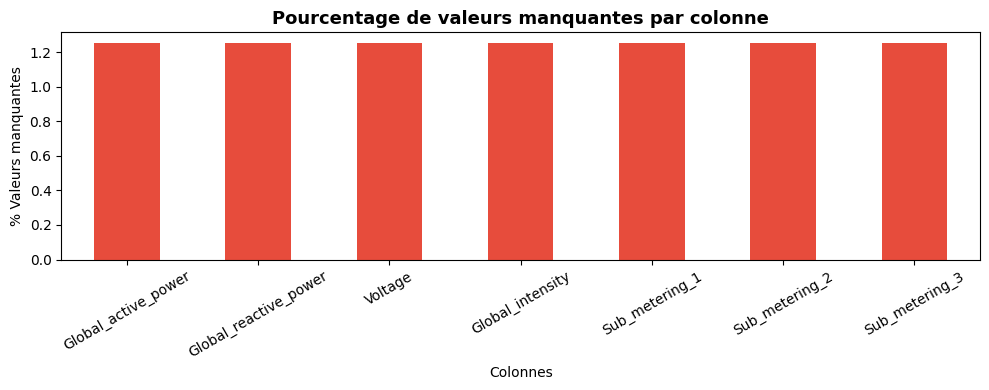

In [8]:
# Visualisation des valeurs manquantes
fig, ax = plt.subplots(figsize=(10, 4))

missing_pct = (df.isnull().sum() / len(df) * 100)
missing_pct.plot(kind='bar', color='#e74c3c', ax=ax)

ax.set_title('Pourcentage de valeurs manquantes par colonne', fontsize=13, fontweight='bold')
ax.set_xlabel('Colonnes')
ax.set_ylabel('% Valeurs manquantes')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('../reports/figures/01_missing_values.png', dpi=150)
plt.show()

## 5. Traitement des valeurs manquantes

Stratégie choisie : **interpolation linéaire temporelle** — adaptée aux séries temporelles à 1 minute.

In [9]:
df_clean = df.interpolate(method='linear', limit_direction='forward')

# Vérification post-traitement
remaining_missing = df_clean.isnull().sum().sum()
print(f'Valeurs manquantes restantes : {remaining_missing}')

Valeurs manquantes restantes : 0


## 6. Feature Engineering temporel

On enrichit le dataset avec des colonnes temporelles utiles pour l'analyse.

In [10]:
df_clean['year']         = df_clean.index.year
df_clean['month']        = df_clean.index.month
df_clean['day']          = df_clean.index.day
df_clean['hour']         = df_clean.index.hour
df_clean['day_of_week']  = df_clean.index.dayofweek   # 0=Lundi, 6=Dimanche
df_clean['day_name']     = df_clean.index.day_name()
df_clean['month_name']   = df_clean.index.month_name()
df_clean['is_weekend']   = df_clean['day_of_week'].isin([5, 6]).astype(int)
df_clean['quarter']      = df_clean.index.quarter

# Consommation en kWh (puissance active * 1min / 60)
df_clean['energy_kwh'] = df_clean['Global_active_power'] / 60

print('Features temporelles ajoutées')
print(f'Colonnes disponibles : {list(df_clean.columns)}')

Features temporelles ajoutées
Colonnes disponibles : ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'year', 'month', 'day', 'hour', 'day_of_week', 'day_name', 'month_name', 'is_weekend', 'quarter', 'energy_kwh']


In [11]:
df_clean.head(3)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,year,month,day,hour,day_of_week,day_name,month_name,is_weekend,quarter,energy_kwh
datetime,,,,,,,,,,,,,,,,,
2006-12-16 17:24:00,4.2160,0.4180,234.8400,18.4000,0.0000,1.0000,17.0000,2006,12,16,17,5,Saturday,December,1,4,0.0703
2006-12-16 17:25:00,5.3600,0.4360,233.6300,23.0000,0.0000,1.0000,16.0000,2006,12,16,17,5,Saturday,December,1,4,0.0893
2006-12-16 17:26:00,5.3740,0.4980,233.2900,23.0000,0.0000,2.0000,17.0000,2006,12,16,17,5,Saturday,December,1,4,0.0896


## 7. Sauvegarde du dataset propre

In [12]:
import os
os.makedirs('../data/processed', exist_ok=True)

df_clean.to_parquet('../data/processed/powerlens_clean.parquet')

print(f'Dataset sauvegardé : data/processed/powerlens_clean.parquet')
print(f'Shape finale : {df_clean.shape[0]:,} lignes × {df_clean.shape[1]} colonnes')

Dataset sauvegardé : data/processed/powerlens_clean.parquet
Shape finale : 2,075,259 lignes × 17 colonnes


## 8. Résumé du notebook

| Étape | Résultat |
|-------|----------|
| Chargement | ~2M lignes, 7 variables numériques |
| Datetime | Index temporel 1-minute sur 47 mois |
| Valeurs manquantes | Traitées par interpolation linéaire |
| Features ajoutées | year, month, hour, day_of_week, is_weekend, energy_kwh |
| Output | `data/processed/powerlens_clean.parquet` |

---
**Prochain notebook :** `02_eda_univariate.ipynb` — Distribution et statistiques par variable